In [ ]:
# Breast Cancer Dataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix as cm
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib as jb

Loading the Data ⏳

In [3]:
dataset = pd.read_csv('breast-cancer.csv')
dataset

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
dataset.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Preprocessing the Data 📈

In [6]:
if 'id' in dataset.columns:
    dataset = dataset.drop('id', axis=1)
dataset 

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [7]:
print(dataset.isnull().sum())

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [8]:
print('Number of unique values: ', dataset.nunique().sum())
print('\n', dataset.nunique())

Number of unique values:  15342

 diagnosis                    2
radius_mean                456
texture_mean               479
perimeter_mean             522
area_mean                  539
smoothness_mean            474
compactness_mean           537
concavity_mean             537
concave points_mean        542
symmetry_mean              432
fractal_dimension_mean     499
radius_se                  540
texture_se                 519
perimeter_se               533
area_se                    528
smoothness_se              547
compactness_se             541
concavity_se               533
concave points_se          507
symmetry_se                498
fractal_dimension_se       545
radius_worst               457
texture_worst              511
perimeter_worst            514
area_worst                 544
smoothness_worst           411
compactness_worst          529
concavity_worst            539
concave points_worst       492
symmetry_worst             500
fractal_dimension_worst    535
dtype

In [9]:
print(dataset.duplicated().sum())

0


In [10]:
#label encoding 
le = LabelEncoder()
dataset['diagnosis'] = le.fit_transform(dataset['diagnosis'])
dataset

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


Exploratory Data Analysis 📊

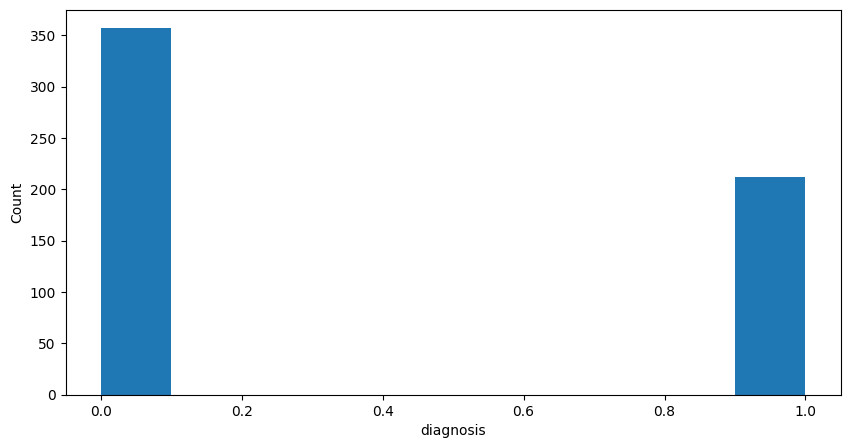

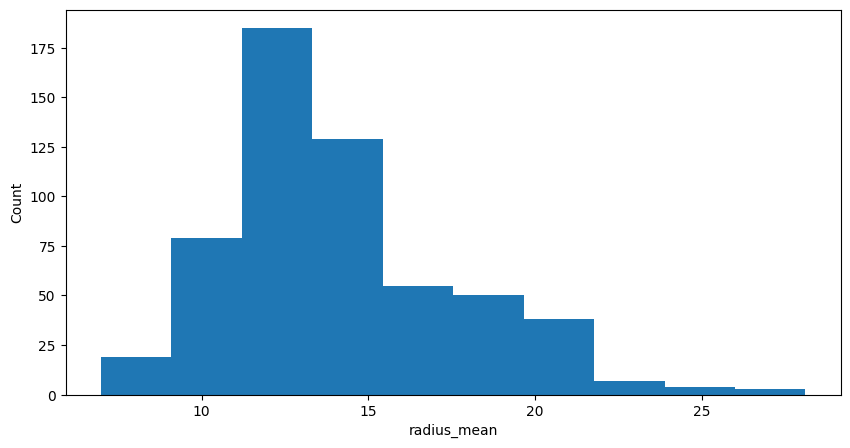

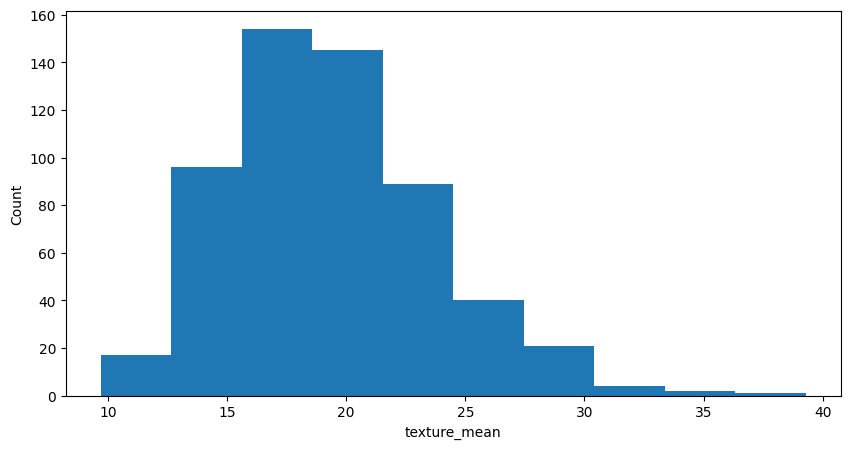

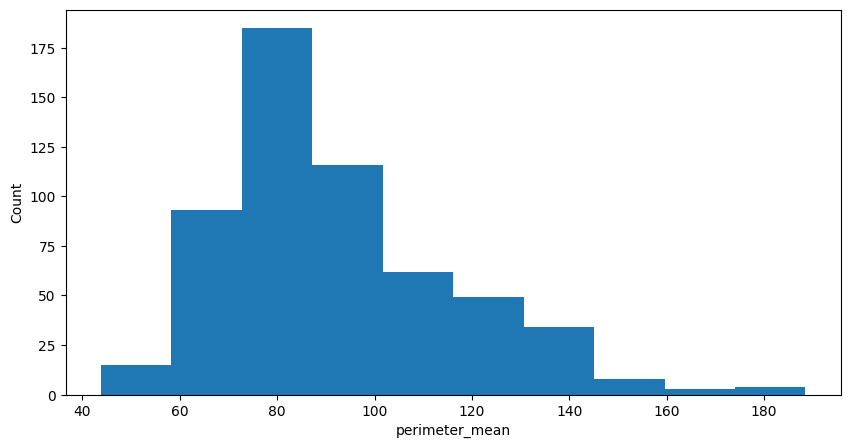

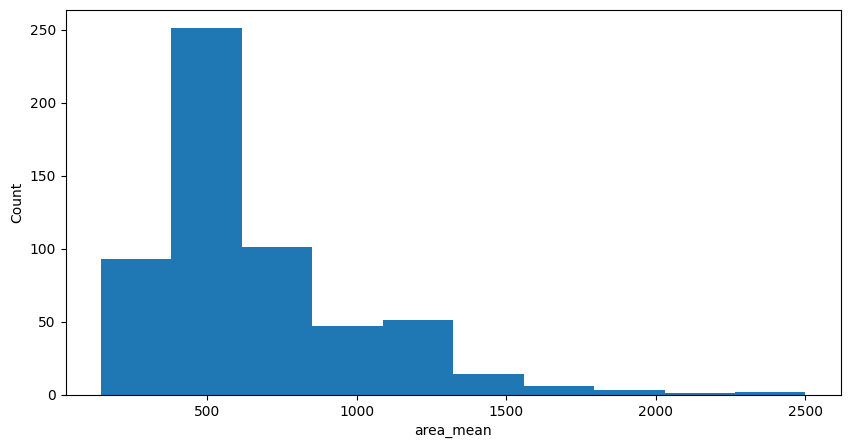

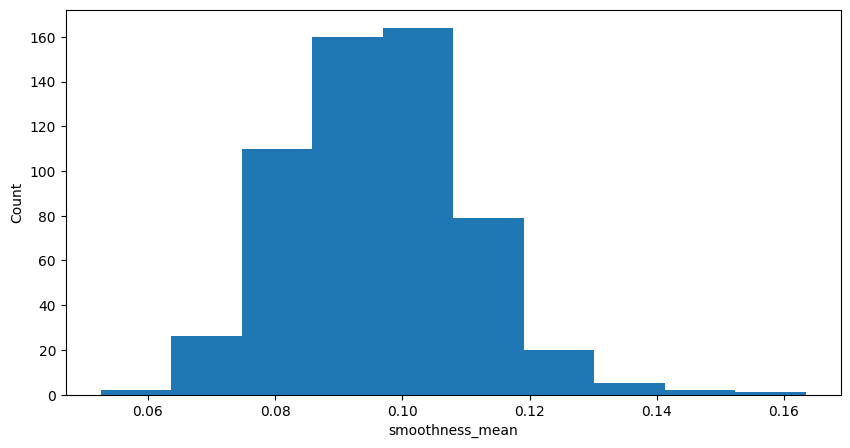

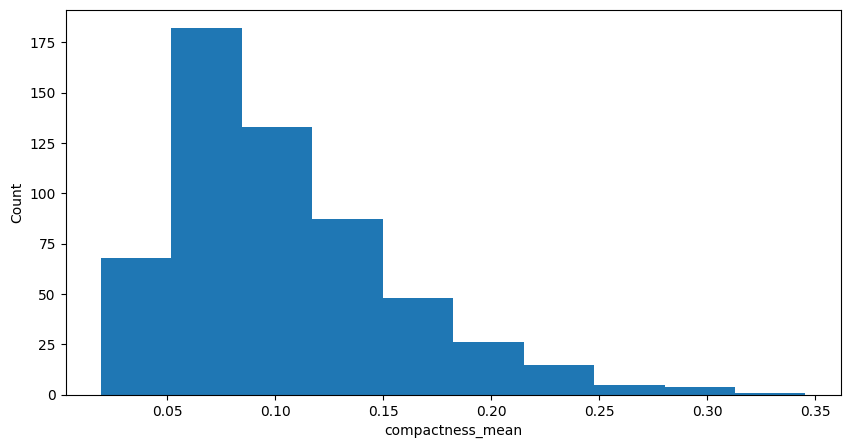

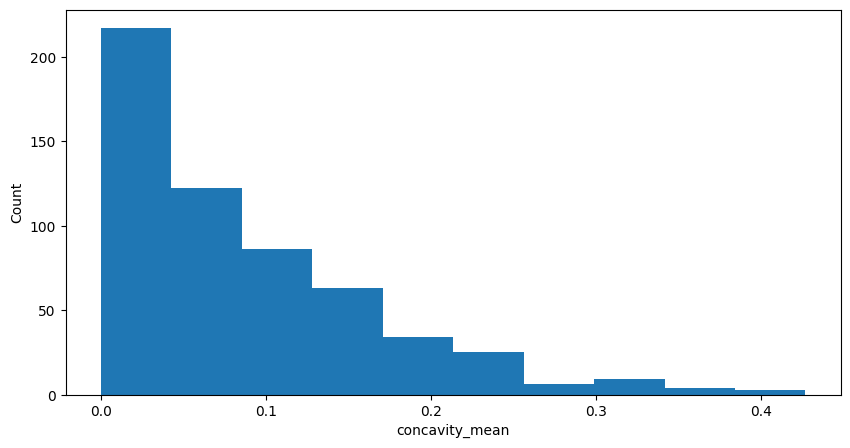

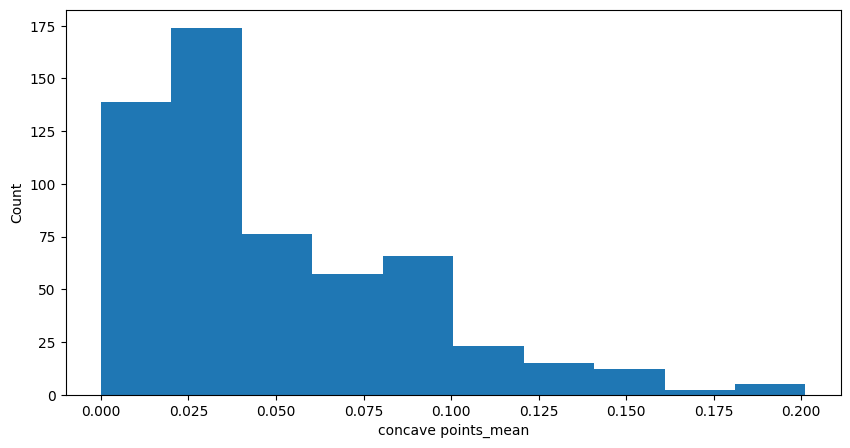

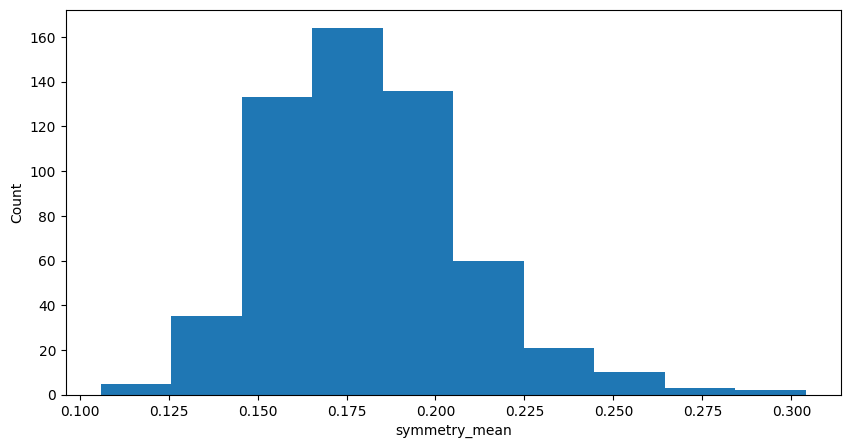

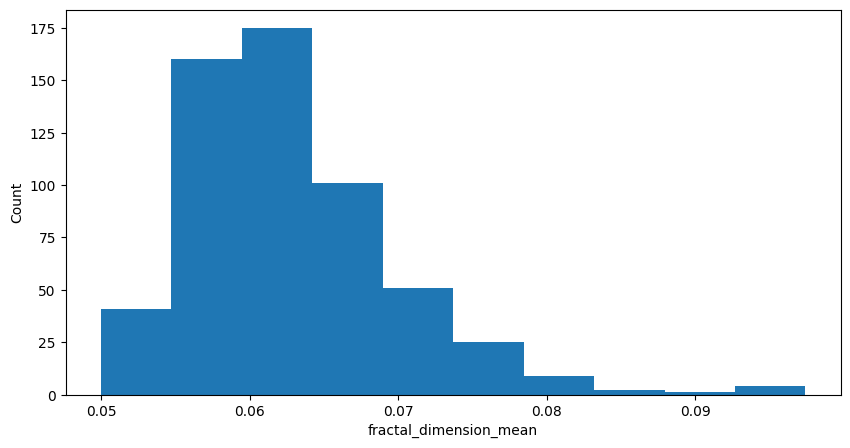

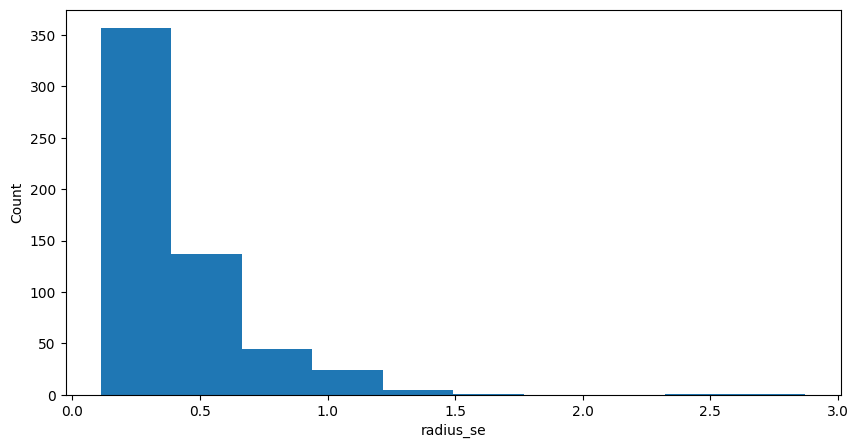

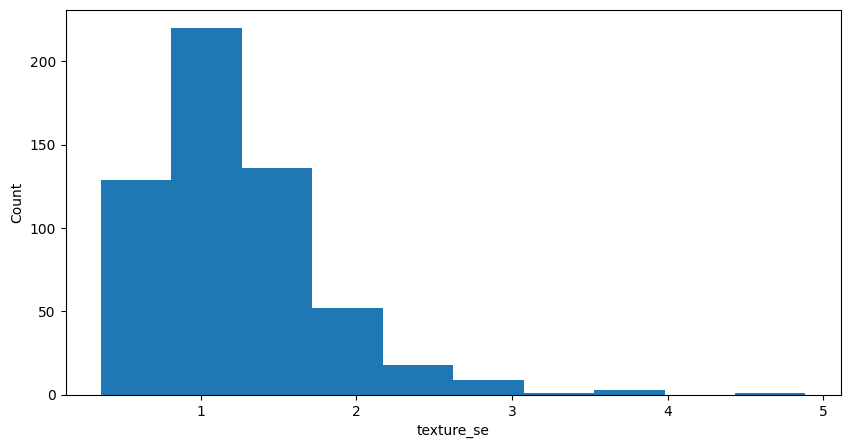

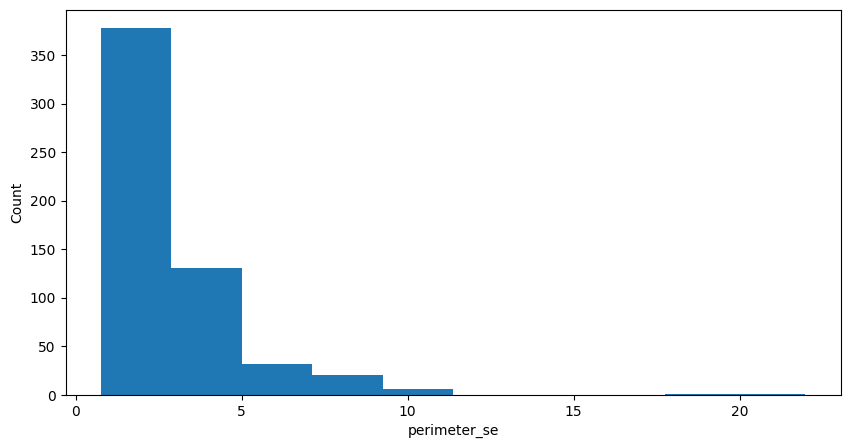

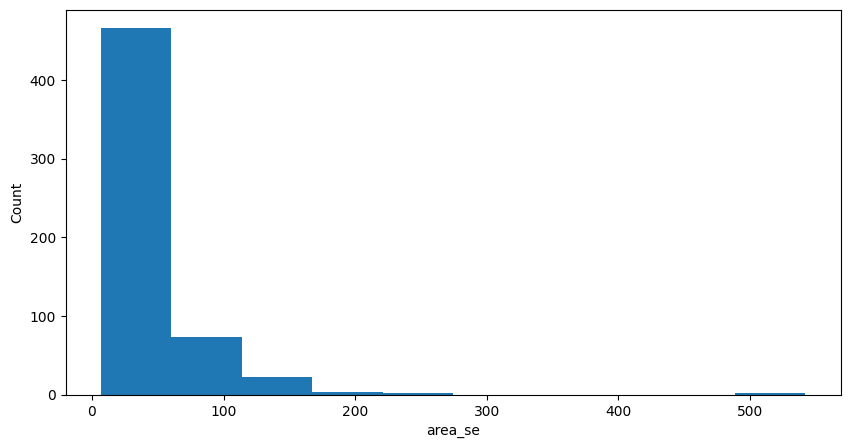

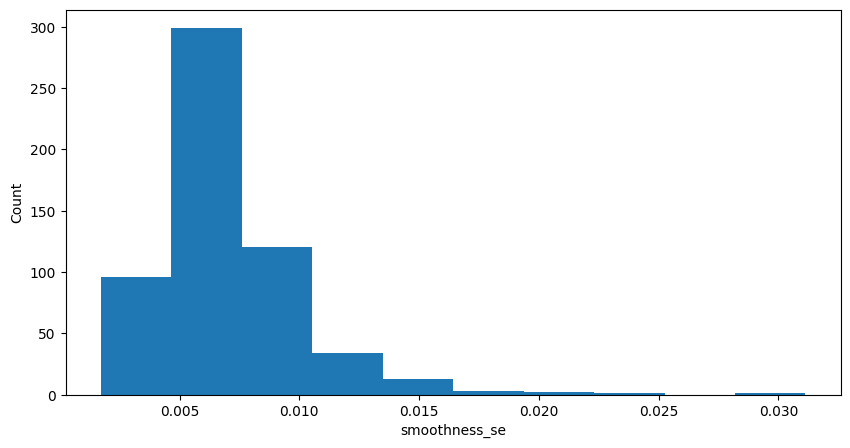

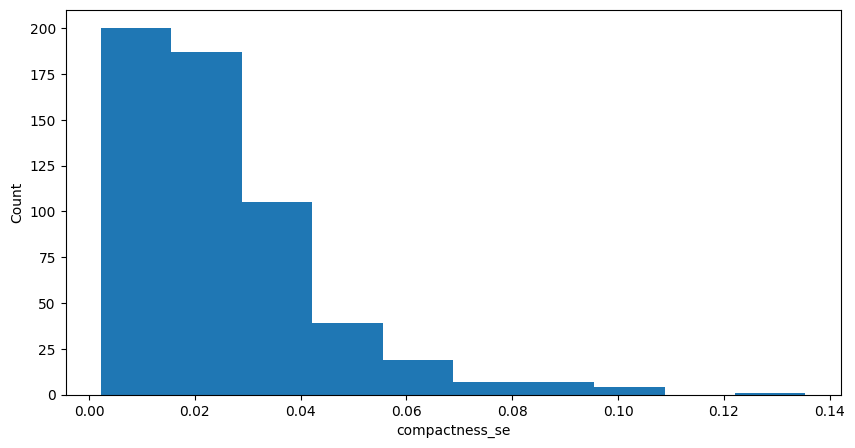

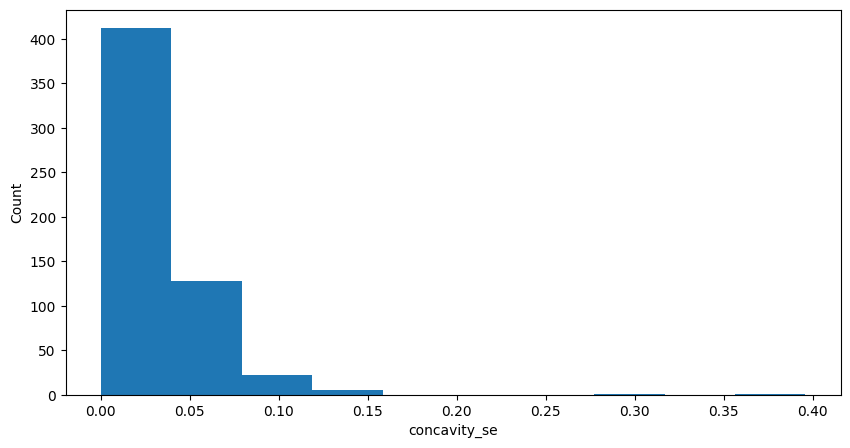

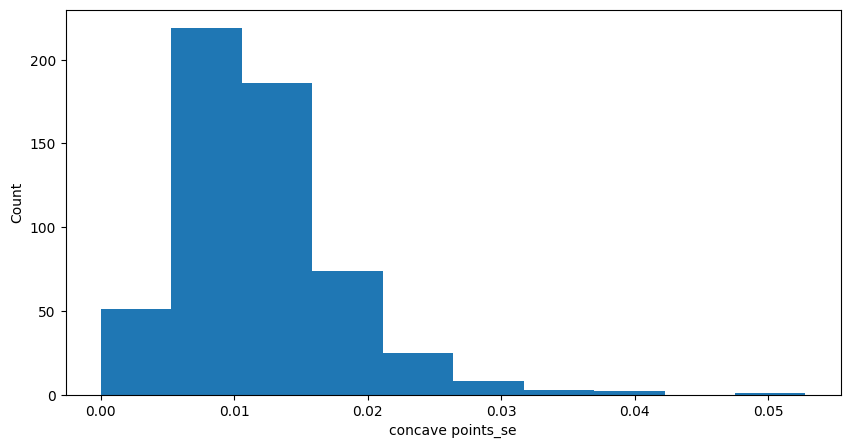

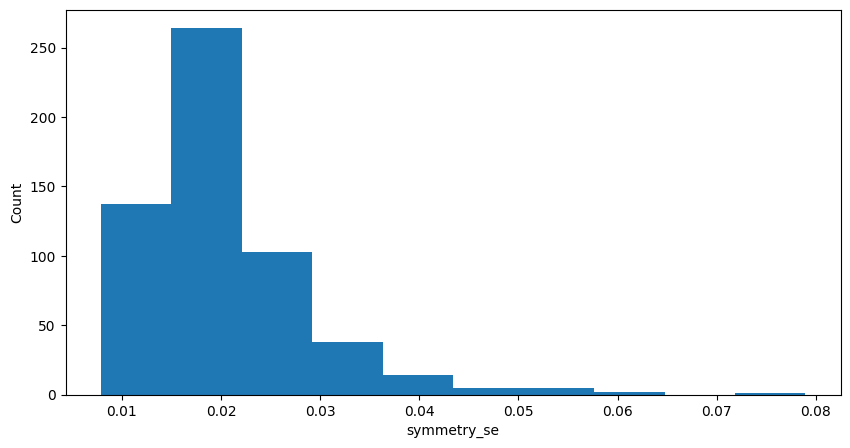

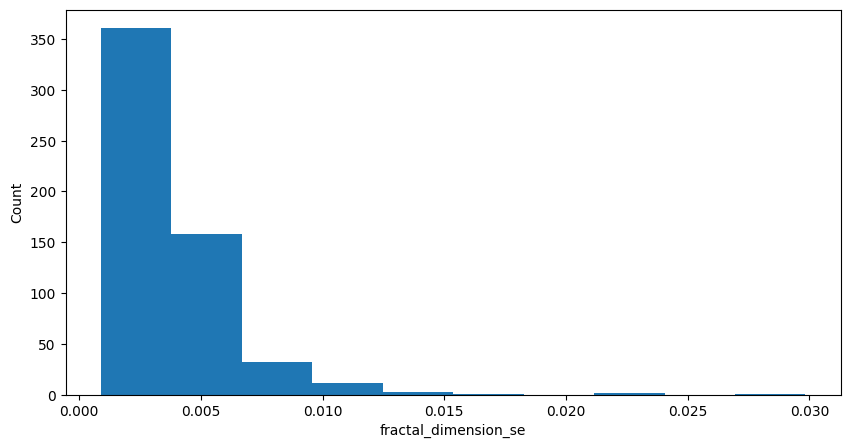

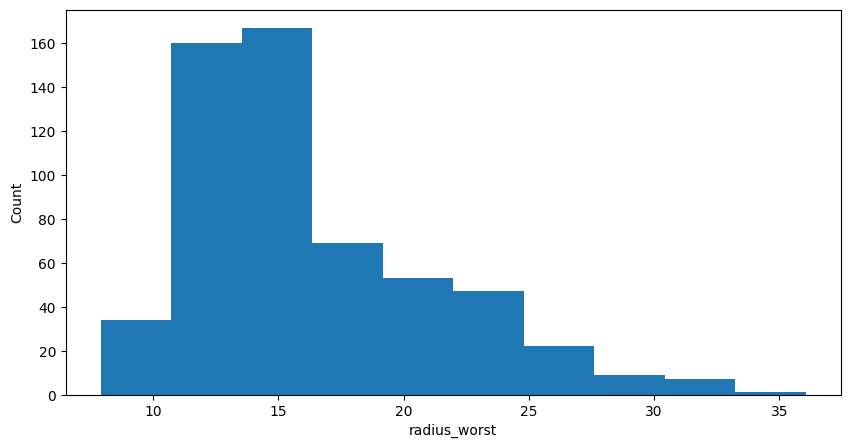

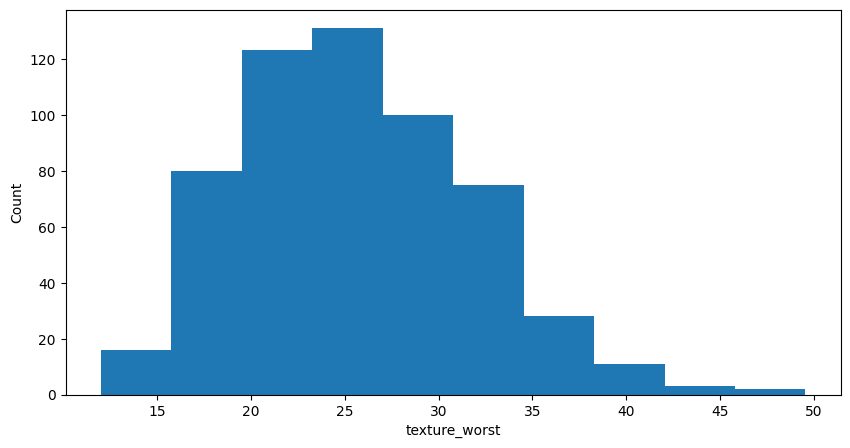

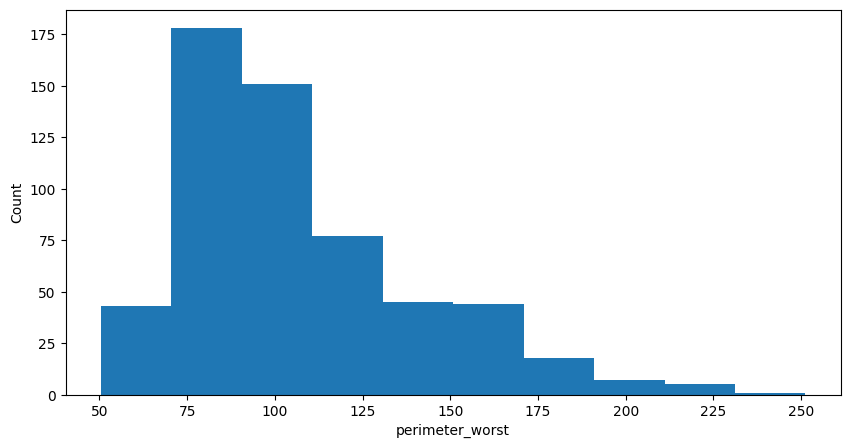

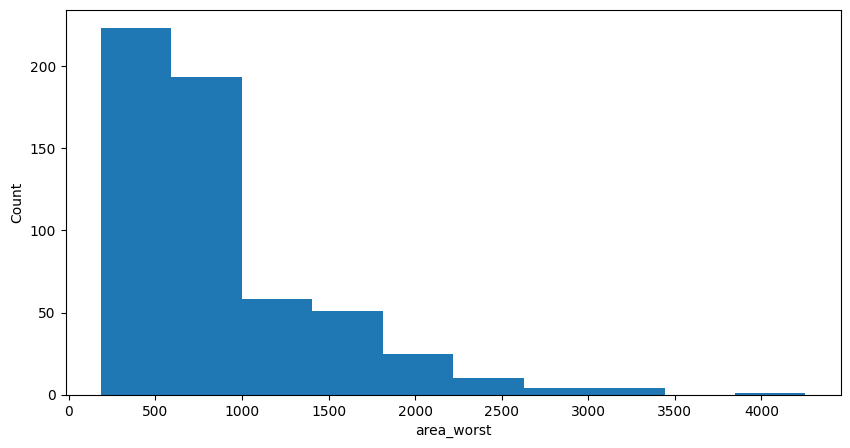

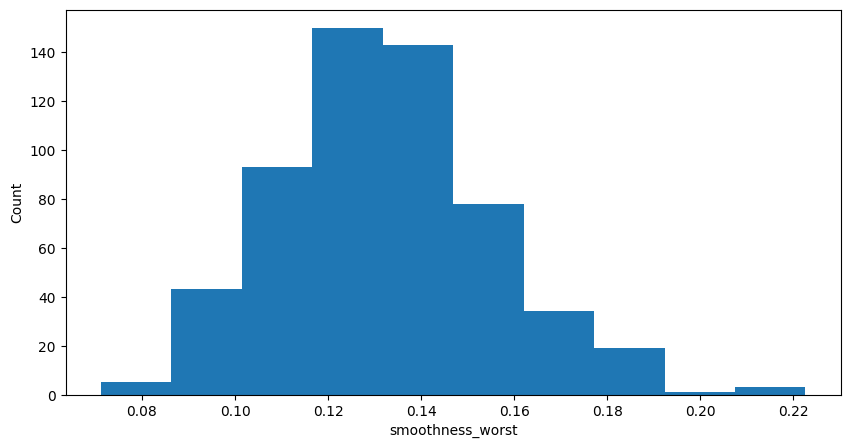

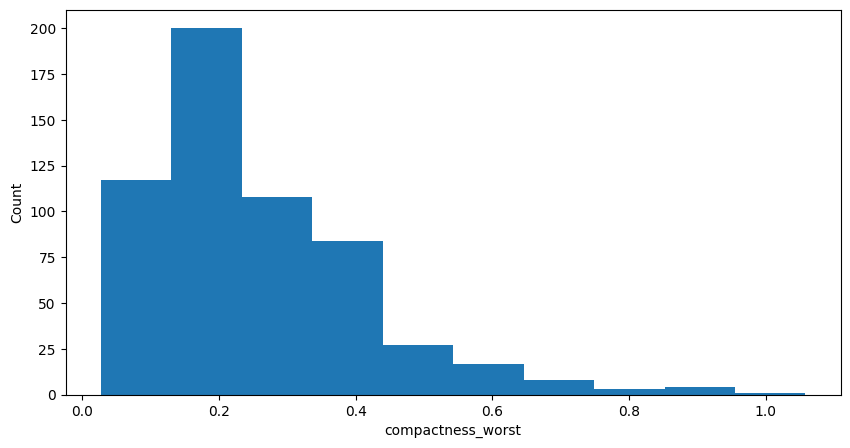

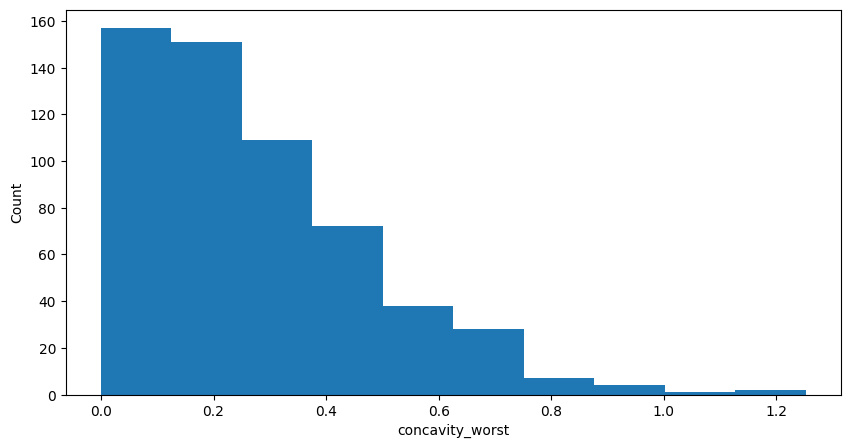

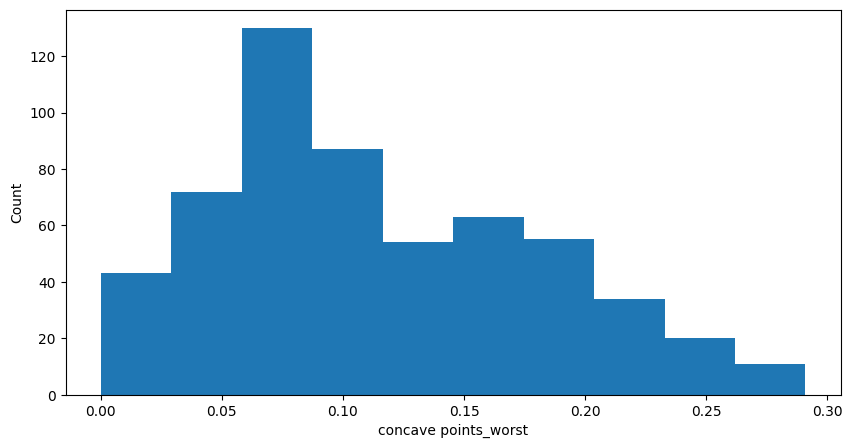

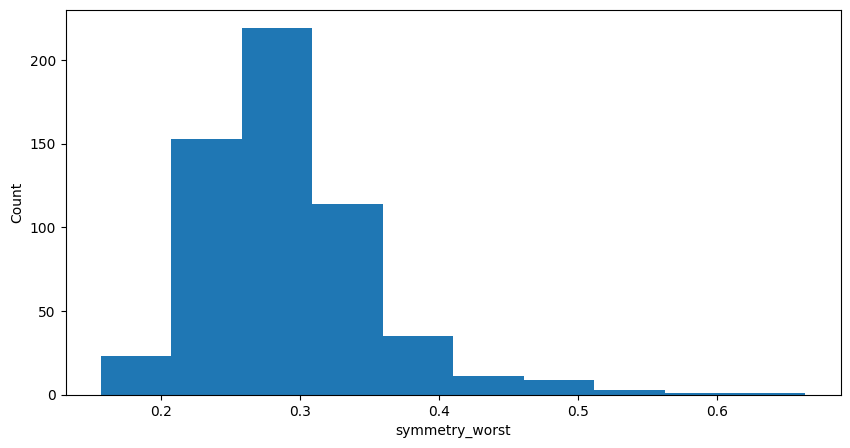

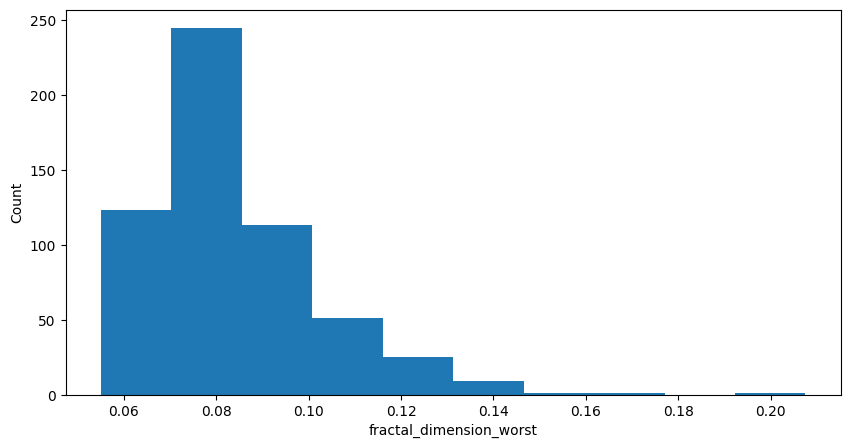

In [11]:
features = dataset.columns
for feature in features:
    plt.figure(figsize=(10, 5))
    plt.hist(dataset[feature])
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

In [14]:
features = dataset.columns
for feature in features:
    q1 = dataset[feature].quantile(0.25)
    q3 = dataset[feature].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    dataset = dataset[(dataset[feature] > lower_bound) & (dataset[feature] < upper_bound)]


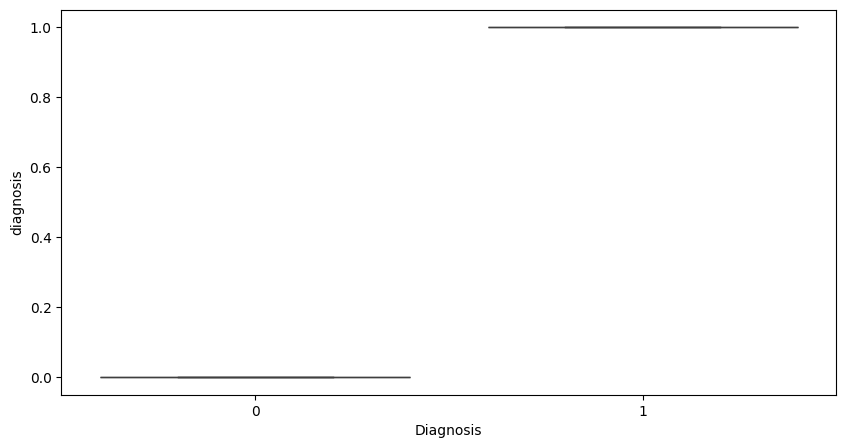

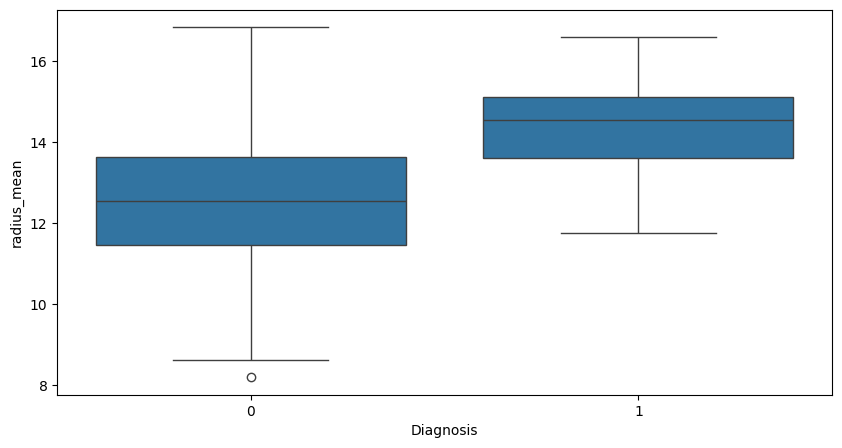

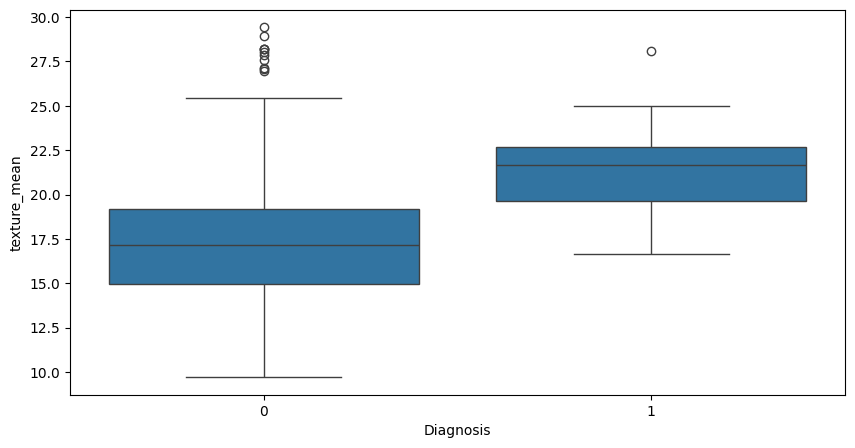

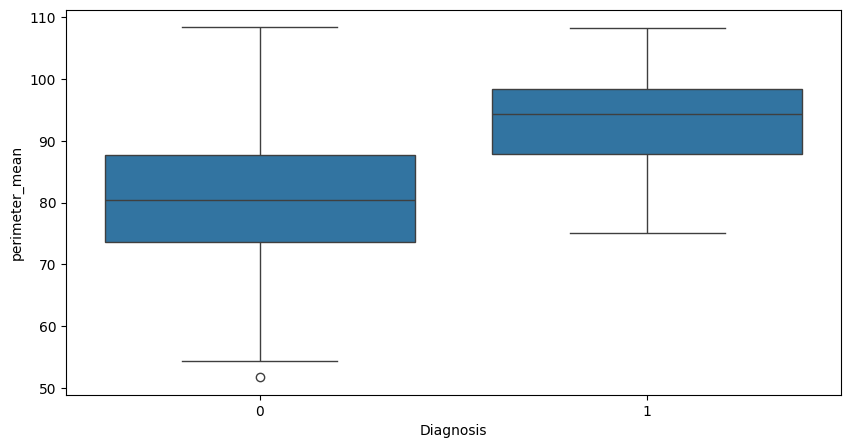

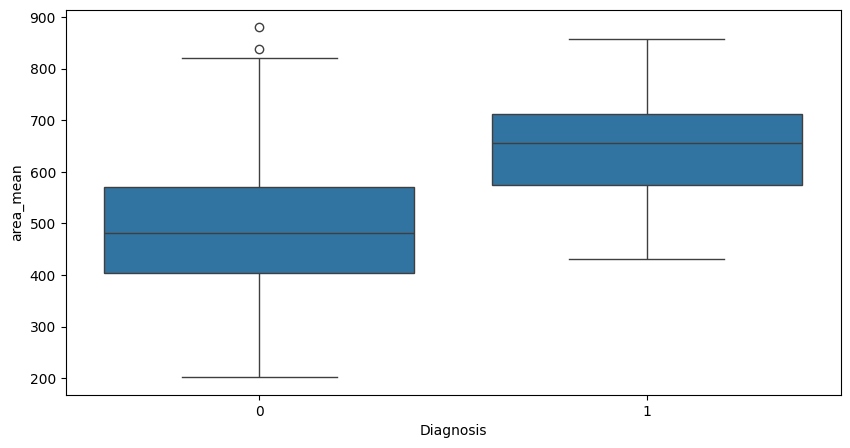

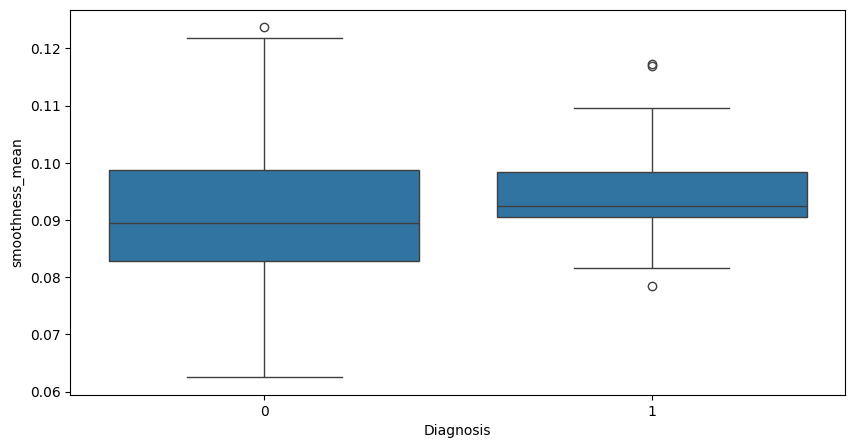

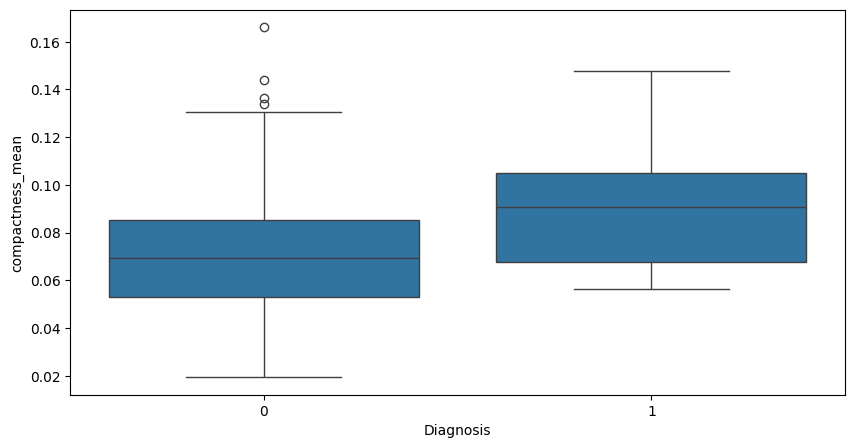

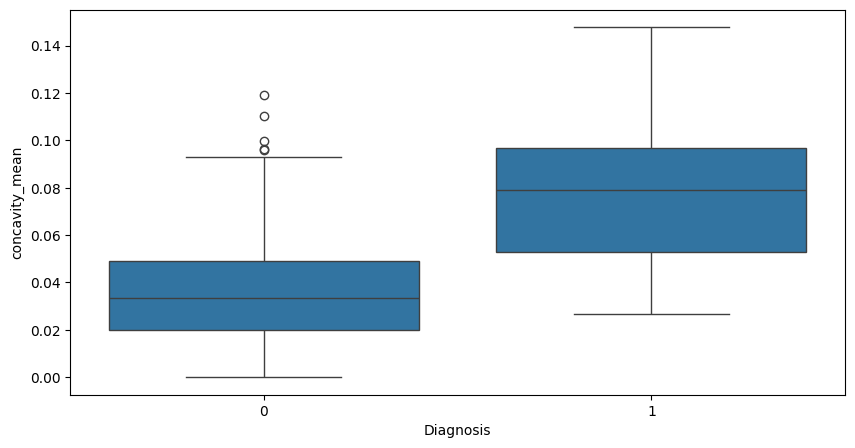

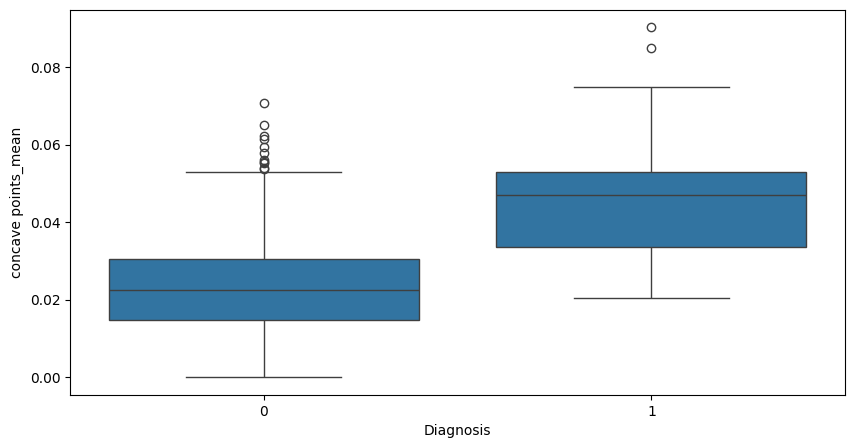

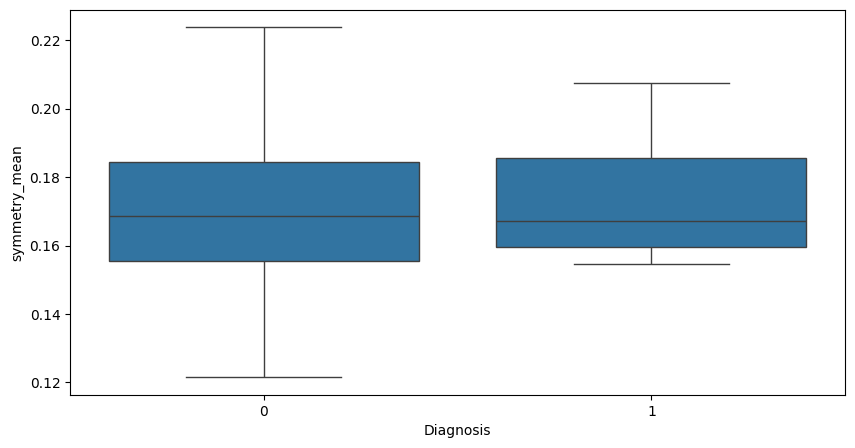

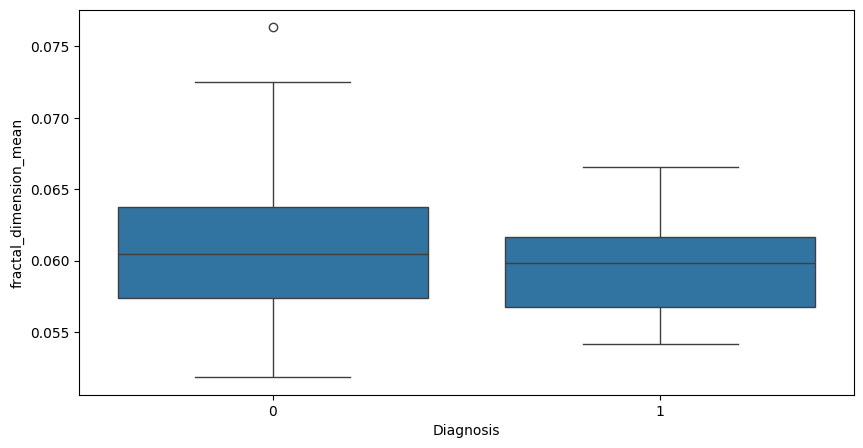

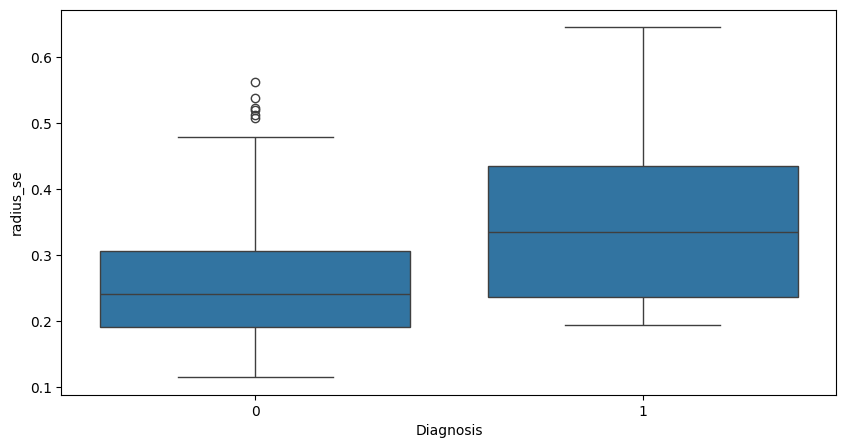

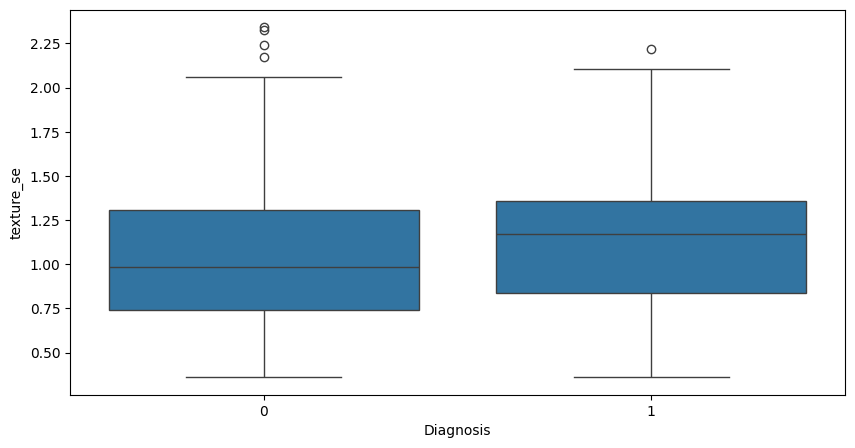

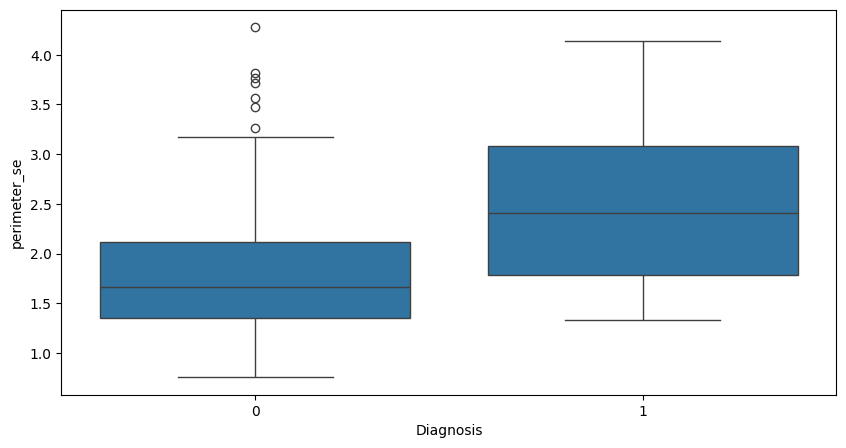

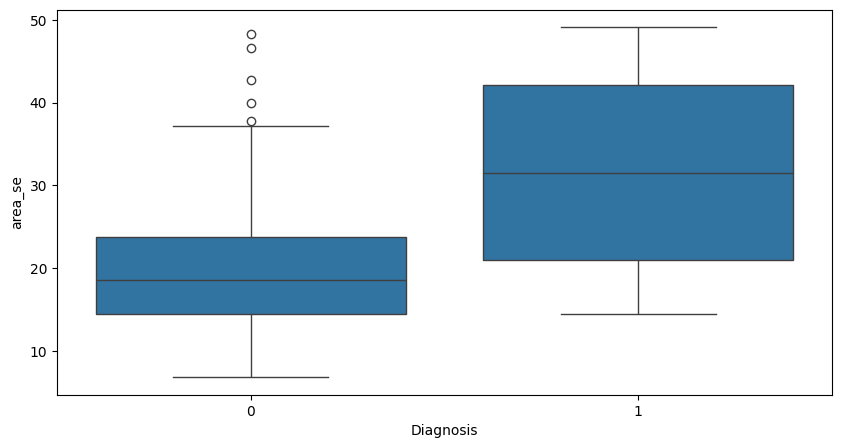

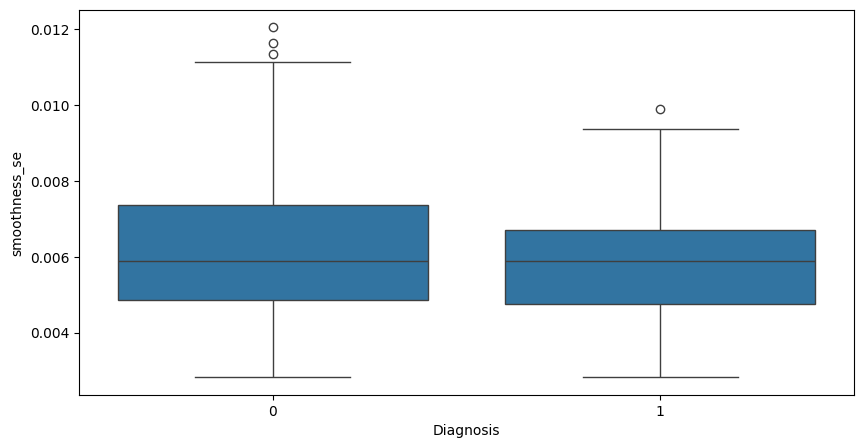

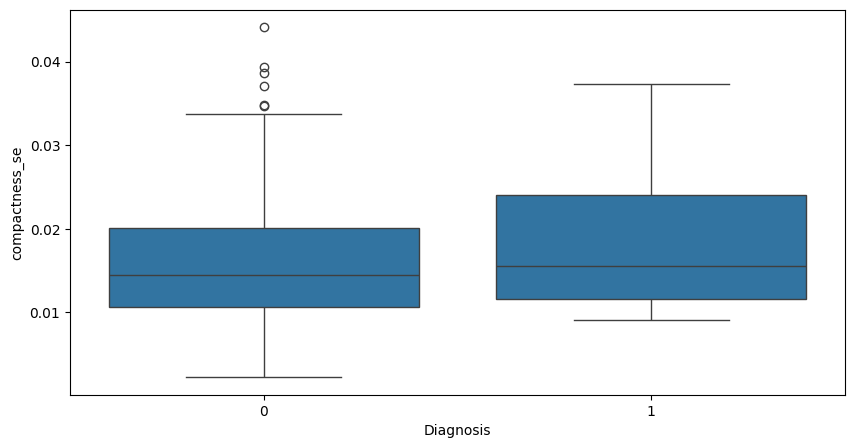

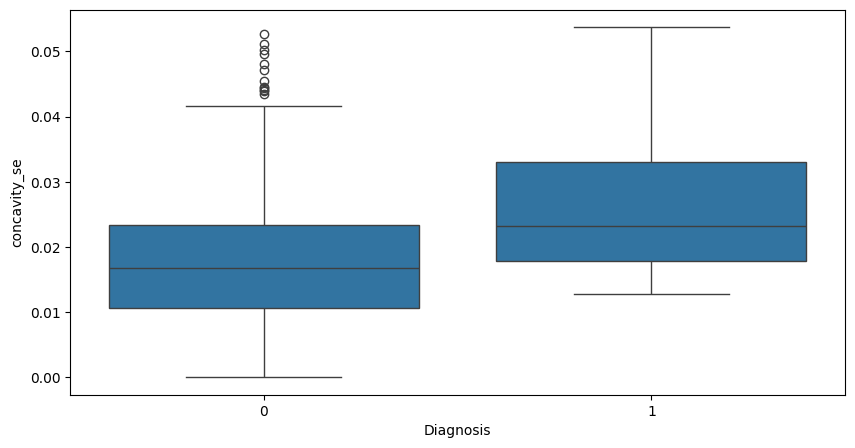

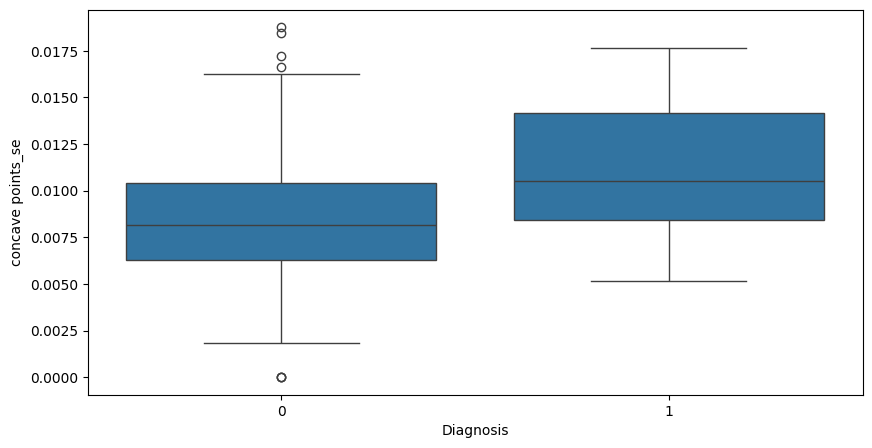

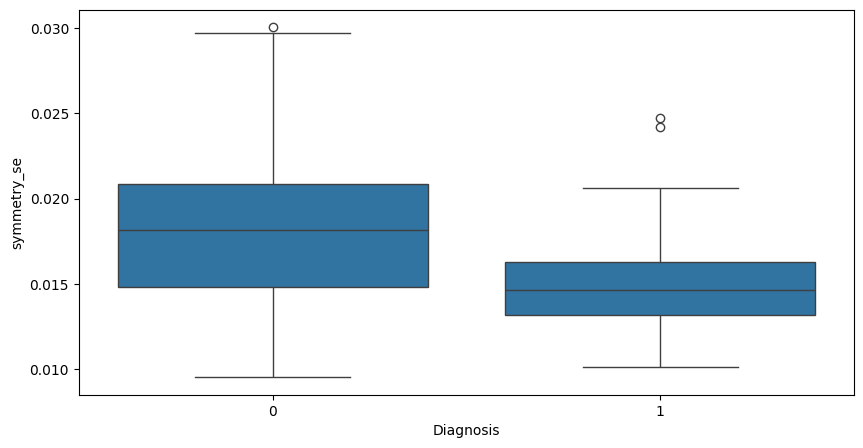

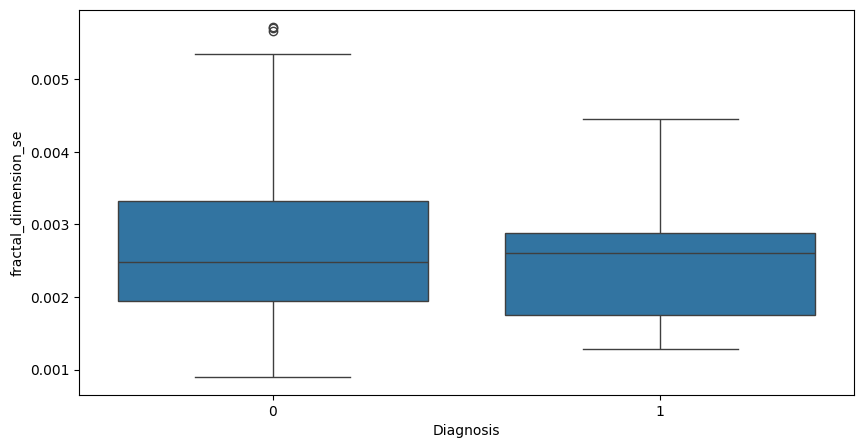

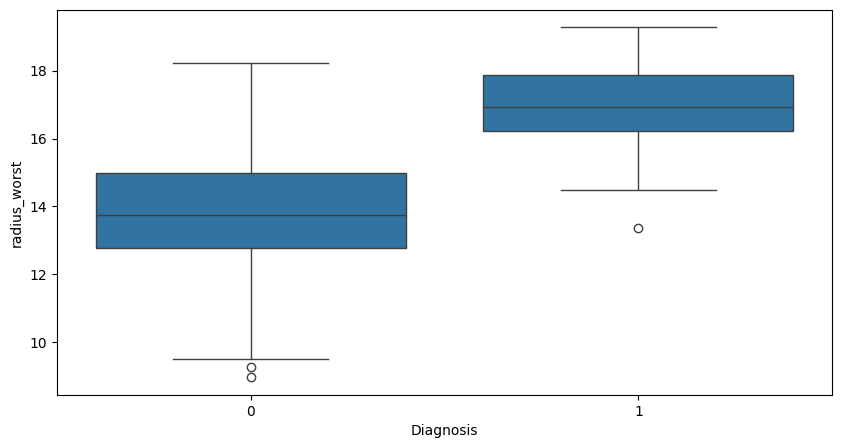

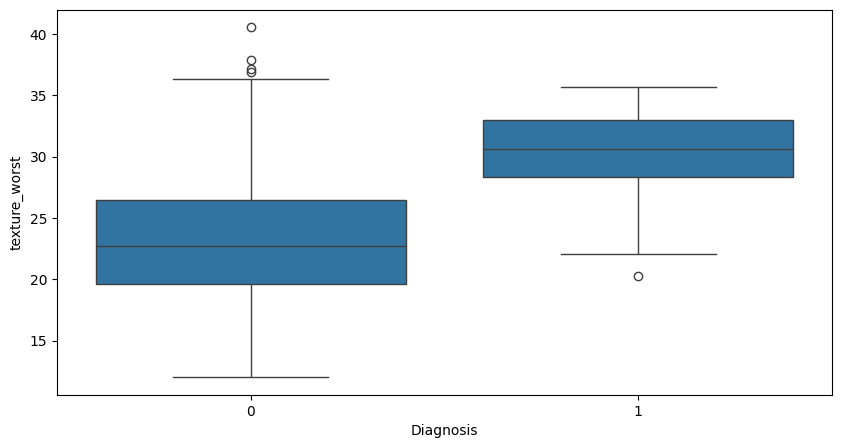

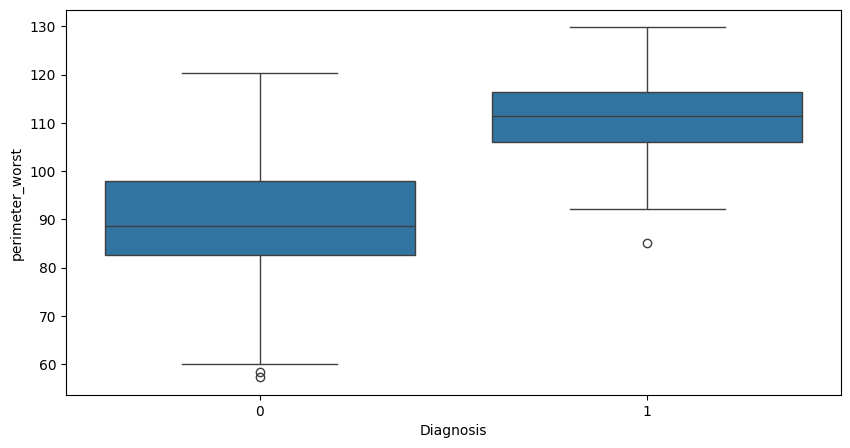

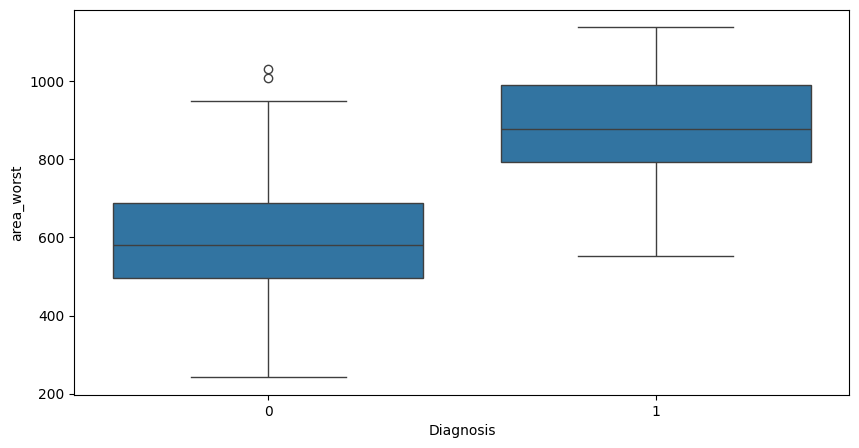

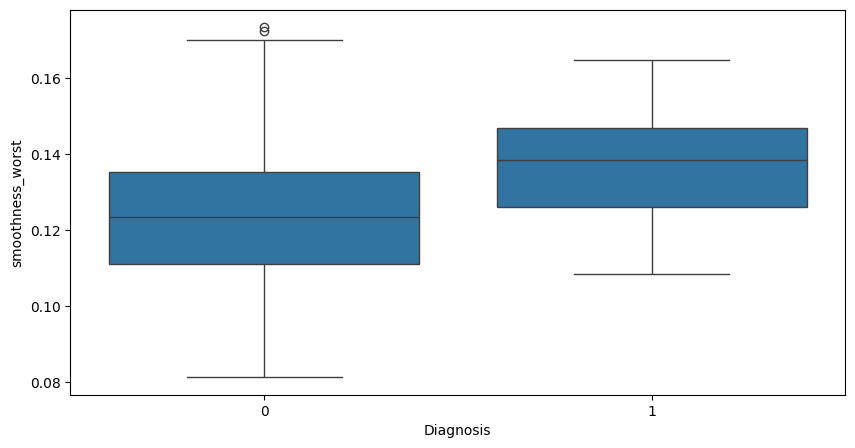

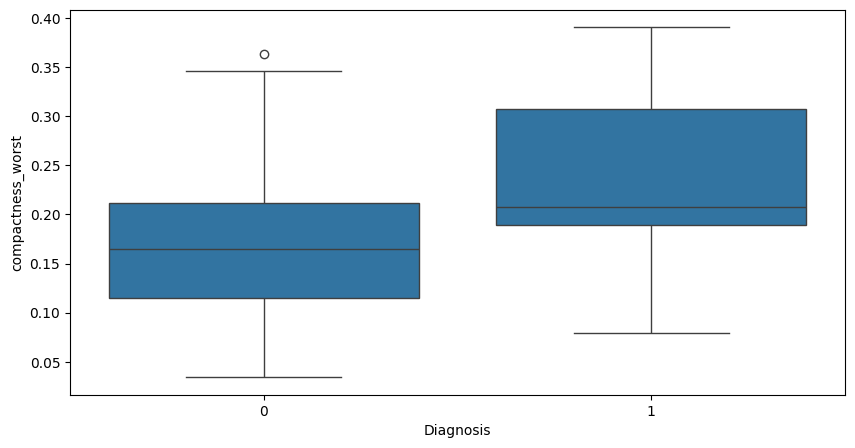

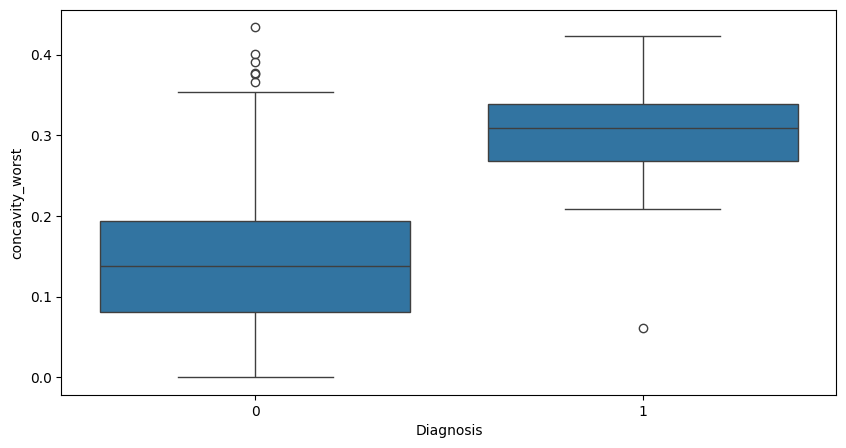

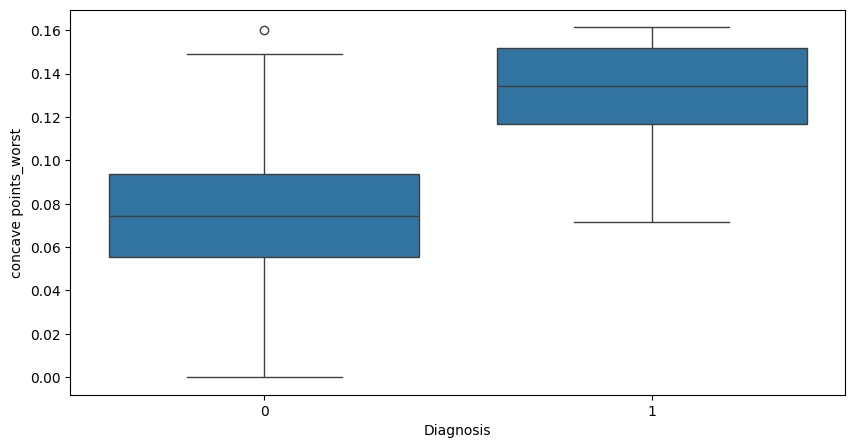

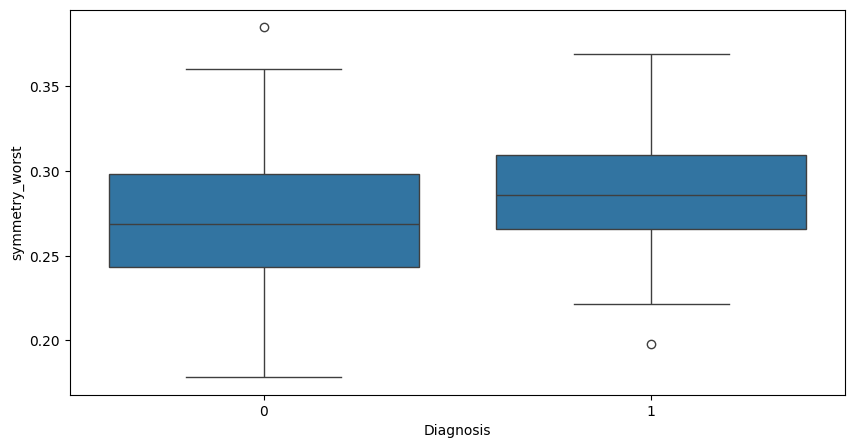

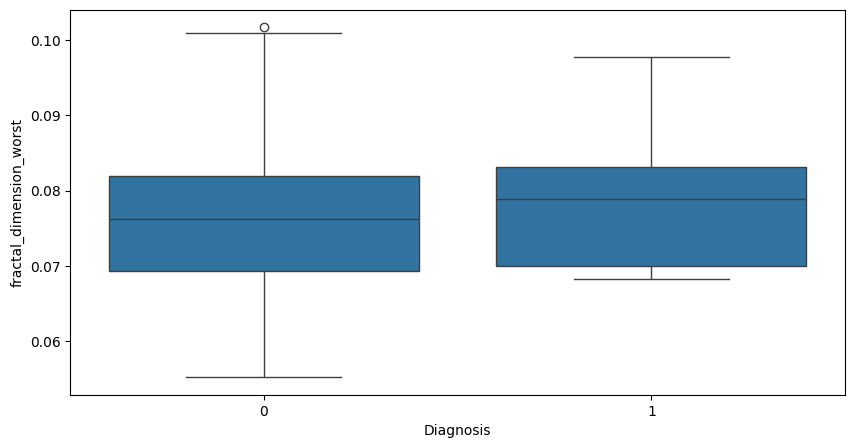

In [15]:
#boxplots again after removing outliers
for feature in features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data = dataset, x = 'diagnosis', y = feature)
    plt.xlabel('Diagnosis')
    plt.ylabel(feature)
    plt.show()

In [16]:
#correlation matrix 
correlation_matrix = dataset.corr()
correlation_matrix

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.312496,0.278581,0.324481,0.334084,0.100188,0.210681,0.444722,0.423595,0.033531,...,0.429559,0.327700,0.431658,0.464664,0.178275,0.274518,0.411858,0.433239,0.109576,0.092933
radius_mean,0.312496,1.000000,0.098912,0.998029,0.995781,-0.091068,0.298559,0.434178,0.554701,-0.083728,...,0.960010,0.077381,0.952612,0.947133,-0.201197,0.311379,0.369832,0.523878,-0.077950,-0.211790
texture_mean,0.278581,0.098912,1.000000,0.101699,0.102452,-0.145048,0.052245,0.140728,0.044810,-0.026563,...,0.134784,0.915850,0.132723,0.141961,-0.069246,0.105710,0.139326,0.087487,-0.076551,-0.034567
perimeter_mean,0.324481,0.998029,0.101699,1.000000,0.993575,-0.049692,0.354838,0.479151,0.593517,-0.056259,...,0.961419,0.082054,0.959464,0.948466,-0.166101,0.359173,0.409636,0.560176,-0.054522,-0.171598
area_mean,0.334084,0.995781,0.102452,0.993575,1.000000,-0.104641,0.285362,0.440086,0.555041,-0.087951,...,0.959951,0.080790,0.952524,0.955705,-0.204442,0.304844,0.373543,0.522100,-0.084516,-0.212394
smoothness_mean,0.100188,-0.091068,-0.145048,-0.049692,-0.104641,1.000000,0.680442,0.404299,0.525072,0.394225,...,-0.047510,-0.089249,-0.014761,-0.060887,0.780201,0.335255,0.253826,0.417630,0.273165,0.430924
compactness_mean,0.210681,0.298559,0.052245,0.354838,0.285362,0.680442,1.000000,0.765334,0.765986,0.411677,...,0.330803,0.067112,0.400661,0.313914,0.504948,0.803175,0.655360,0.708257,0.318485,0.550898
concavity_mean,0.444722,0.434178,0.140728,0.479151,0.440086,0.404299,0.765334,1.000000,0.858145,0.296817,...,0.474015,0.178034,0.531735,0.478111,0.366124,0.721295,0.871724,0.796971,0.218880,0.357772
concave points_mean,0.423595,0.554701,0.044810,0.593517,0.555041,0.525072,0.765986,0.858145,1.000000,0.274055,...,0.580661,0.077680,0.620854,0.575155,0.389435,0.590491,0.638008,0.864133,0.162583,0.236100
symmetry_mean,0.033531,-0.083728,-0.026563,-0.056259,-0.087951,0.394225,0.411677,0.296817,0.274055,1.000000,...,-0.063793,-0.013651,-0.023013,-0.073930,0.274367,0.281615,0.227579,0.246753,0.642203,0.204007


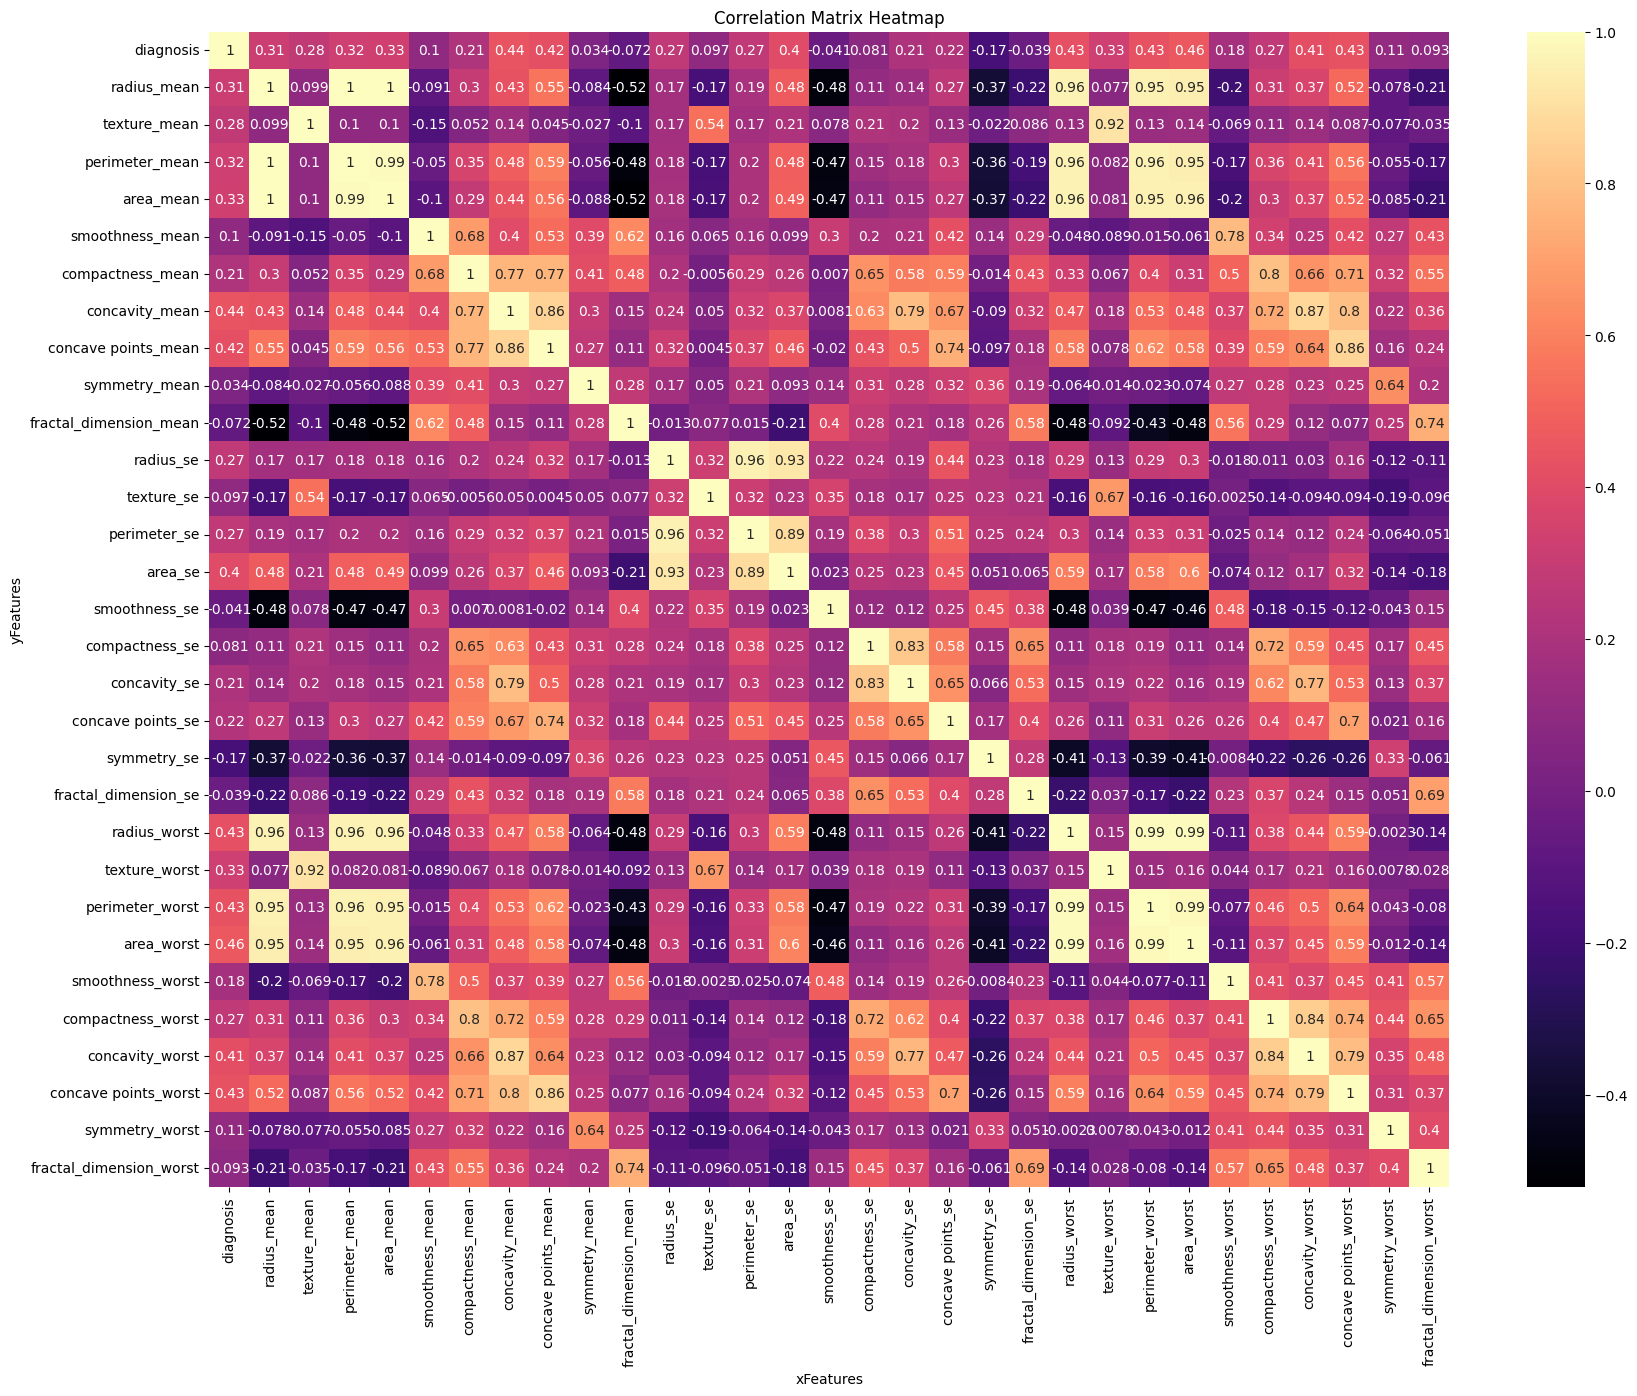

In [17]:
#now using heatmap 
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap = 'magma')
plt.title('Correlation Matrix Heatmap')
plt.xlabel('xFeatures')
plt.ylabel('yFeatures')
plt.show()

In [18]:
# now dropping some features
features_drop = ['smoothness_mean', 'symmetry_mean', 'fractal_dimension_mean', 'texture_se', 'smoothness_se', 'compactness_se', 'symmetry_se', 'fractal_dimension_se', 'smoothness_worst', 'symmetry_worst', 'fractal_dimension_worst']
dataset = dataset.drop(columns=[col for col in features_drop if col in dataset.columns])

In [19]:
dataset.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,compactness_mean,concavity_mean,concave points_mean,radius_se,perimeter_se,area_se,concavity_se,concave points_se,radius_worst,texture_worst,perimeter_worst,area_worst,compactness_worst,concavity_worst,concave points_worst
16,1,14.680,20.13,94.74,684.5,0.07200,0.07395,0.05259,0.4727,3.195,45.40,0.01998,0.01109,19.07,30.88,123.40,1138.0,0.18710,0.29140,0.16090
19,0,13.540,14.36,87.46,566.3,0.08129,0.06664,0.04781,0.2699,2.058,23.56,0.02387,0.01315,15.11,19.26,99.70,711.2,0.17730,0.23900,0.12880
20,0,13.080,15.71,85.63,520.0,0.12700,0.04568,0.03110,0.1852,1.383,14.67,0.01698,0.00649,14.50,20.49,96.09,630.5,0.27760,0.18900,0.07283
21,0,9.504,12.44,60.34,273.9,0.06492,0.02956,0.02076,0.2773,1.909,15.70,0.01985,0.01421,10.23,15.66,65.13,314.9,0.11480,0.08867,0.06227
37,0,13.030,18.42,82.61,523.8,0.03766,0.02562,0.02923,0.1839,1.170,14.16,0.01343,0.01164,13.30,22.81,84.46,545.9,0.04619,0.04833,0.05013


Pipeline

In [ ]:
X = dataset.drop('diagnosis', axis=1)
y = dataset['diagnosis']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()


In [21]:
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Combine transformers
preprocessor = ColumnTransformer([
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

In [22]:
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier())
])

In [23]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])


In [24]:
nb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
dt_pipeline.fit(X_train, y_train)
dt_preds = dt_pipeline.predict(X_test)

In [27]:
print('Decision Tree Accuracy: ', accuracy_score(y_test, dt_preds) * 100)

Decision Tree Accuracy:  82.14285714285714


In [28]:
print(classification_report(y_test, dt_preds))

              precision    recall  f1-score   support

           0       0.94      0.87      0.90        53
           1       0.00      0.00      0.00         3

    accuracy                           0.82        56
   macro avg       0.47      0.43      0.45        56
weighted avg       0.89      0.82      0.85        56



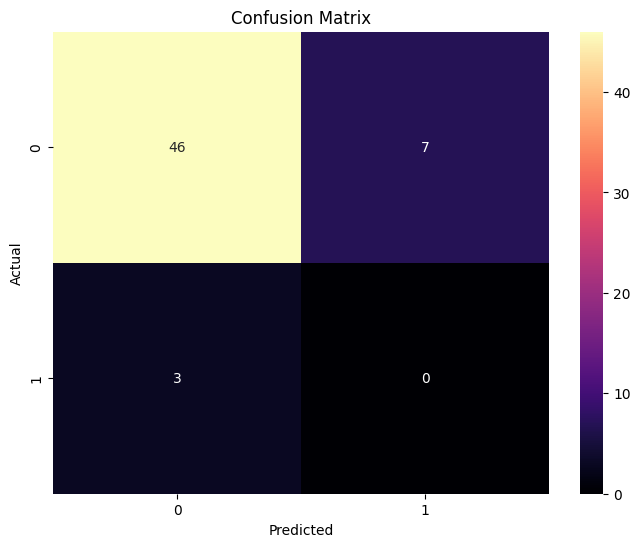

In [29]:
#confusion matrix
confusion_matrix2 = cm(y_test, dt_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix2, annot=True, cmap='magma')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [30]:
knn_pipeline.fit(X_train, y_train)
knn_preds = knn_pipeline.predict(X_test)

In [31]:
print('KNN Accuracy: ', accuracy_score(y_test, knn_preds) * 100)

KNN Accuracy:  94.64285714285714


In [32]:
print(classification_report(y_test, knn_preds))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97        53
           1       0.50      0.33      0.40         3

    accuracy                           0.95        56
   macro avg       0.73      0.66      0.69        56
weighted avg       0.94      0.95      0.94        56



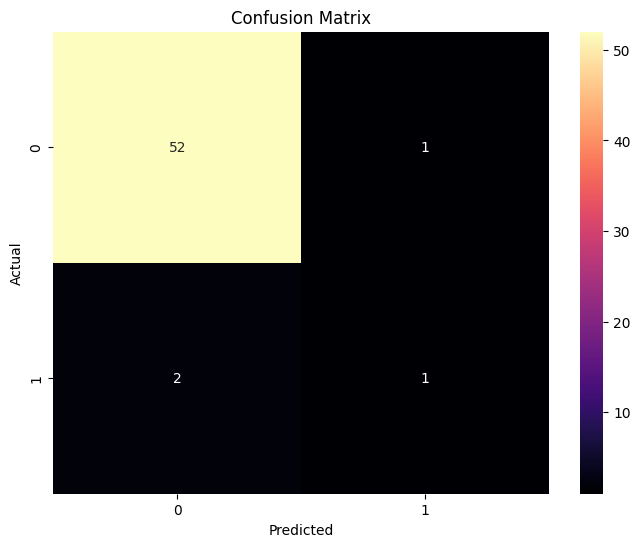

In [33]:
#confusion matrix
confusion_matrix2 = cm(y_test, knn_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix2, annot=True, cmap='magma')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [34]:
nb_pipeline.fit(X_train, y_train)
nb_preds = nb_pipeline.predict(X_test)

In [35]:
print('Naive Bayes Accuracy: ', accuracy_score(y_test, nb_preds) * 100)

Naive Bayes Accuracy:  83.92857142857143


In [36]:
print(classification_report(y_test, nb_preds))

              precision    recall  f1-score   support

           0       1.00      0.83      0.91        53
           1       0.25      1.00      0.40         3

    accuracy                           0.84        56
   macro avg       0.62      0.92      0.65        56
weighted avg       0.96      0.84      0.88        56



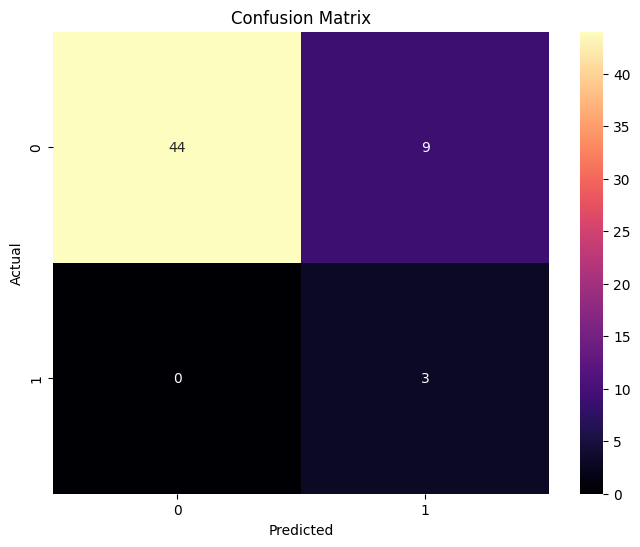

In [37]:
#confusion matrix
confusion_matrix2 = cm(y_test, nb_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix2, annot=True, cmap='magma')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [39]:
dt_cv = cross_val_score(dt_pipeline, X_train, y_train, cv=5)
knn_cv = cross_val_score(knn_pipeline, X_train, y_train, cv=5)
nb_cv = cross_val_score(nb_pipeline, X_train, y_train, cv=5)

print("Decision Tree CV Mean:", dt_cv.mean() * 100)
print("KNN CV Mean:", knn_cv.mean() * 100)
print("Naive Bayes CV Mean:", nb_cv.mean() * 100)


Decision Tree CV Mean: 90.92929292929293
KNN CV Mean: 94.55555555555556
Naive Bayes CV Mean: 88.22222222222223
